# Dynamic Hedge Pairs Trading — *without* Benjamini-Hochberg
## `pairs_trading_03_yahoo.ipynb`

Identical pipeline to `pairs_trading_02_yahoo.ipynb` — cointegration screen → Kalman hedge → walk-forward pair selection → in-sample & out-of-sample backtests with performance metrics → limitations — with **one deliberate change: no Benjamini-Hochberg FDR correction** on the cointegration screen (`fdr_method="none"`, raw p-values).

The intent is to isolate the effect of dropping multiple-testing control. **It still does not, and the
reason is worth more than the intended result.**

The correction now visibly bites on the screen: under Benjamini-Hochberg **279** of 118,828 pairs clear
the dual gate, and without it **6,102** do — twenty-two times as many. That difference is real and it is
printed below. Yet this notebook still reproduces `pairs_trading_02_yahoo.ipynb` exactly: same selected
pair, same in-sample Sharpe, same trades.

The filters are **nested**. Benjamini-Hochberg removes the pairs with the *weakest* p-values; the shortlist
is the top 200 by a blended Engle-Granger/Johansen *rank*, which keeps the *strongest*. Since
$200 \le 279 \le 6{,}102$ and both pools are ordered the same way, the top 200 of the corrected pool and
the top 200 of the uncorrected pool are the **same 200 pairs**. Every pair the correction removes was
already going to be discarded one line later.

So the ablation can only bite under one of two conditions, neither of which holds here:

* the shortlist is **larger** than the number of survivors — take the top 500 and the corrected pool runs
  out at 279, forcing it to stop where the uncorrected one keeps going; or
* selection is **not ordered by p-value** — if the shortlist were drawn by any other criterion, the
  correction would change which pairs are available to it.

That is the honest lesson, and it generalizes past this notebook: **a significance filter placed upstream
of a stricter ranking filter is decorative.** It changes a reported count and nothing else. Notebook 11
finds FDR control worth +0.40 Sharpe against −0.41 for distance selection precisely because there the
survivors *are* the selection, with no tighter cut behind them.



## 0. Environment setup

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
print("pairs version:", pairs.__version__)
print("pairs path   :", Path(pairs.__file__).relative_to(repo_root))

pairs version: 0.1.0
pairs path   : pairs/__init__.py


In [2]:
# Install the package (editable) if running in a fresh environment
# %pip install -e "..[notebooks]"  # uncomment if needed

# 1. Data Loading & Quality Filtering

We load daily OHLCV prices for the combined S&P 500 + NASDAQ-100 universe
(~517 tickers) over the **training window 2020-01-01 → 2025-12-31**, then
drop tickers whose coverage does not span the full period.

In [3]:
from pairs import load_universe, load_prices

tickers = load_universe("spx_ndx_combined")
print(f"Universe: {len(tickers)} tickers")

Universe: 517 tickers


In [4]:
# ── Load training prices ──────────────────────────────────────────────────────
start_date = "2020-01-01"
end_date   = "2025-12-31"

# Prices are cached on first run so the notebook is reproducible offline afterwards.
# This matters more than it looks: Yahoo re-bases its adjusted close after every
# corporate action, so a fresh download months later returns different *levels*
# for any name that has since split or spun off. Pinning the file freezes the basis.
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
# the window is part of the key: change the dates and it re-downloads
_px_cache = CACHE / f"nb03_train_{start_date}_{end_date}.parquet"
if _px_cache.exists():
    df_train, failed = pd.read_parquet(_px_cache), []
else:
    df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)
    df_train.to_parquet(_px_cache)

print(f"Loaded {len(df_train):,} rows for {df_train.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

Loaded 753,000 rows for 505 tickers


In [5]:
# ── Quality filter: keep only full-coverage tickers ──────────────────────────
lvl_names      = list(df_train.index.names)
time_lvl_name  = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

starts = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).min())
ends   = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).max())

tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index
df_filtered     = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

n_orig    = df_train.index.get_level_values('ticker').nunique()
n_kept    = df_filtered.index.get_level_values('ticker').nunique()
dropped   = set(tickers) - set(tickers_to_keep)
print(f"Tickers: {n_orig} total → {n_kept} kept ({n_orig - n_kept} dropped for incomplete coverage)")
print(f"Dropped: {sorted(dropped)}")

Tickers: 505 total → 488 kept (17 dropped for incomplete coverage)
Dropped: ['ABNB', 'APP', 'ARM', 'AVB', 'BK', 'CARR', 'CEG', 'COIN', 'CTRA', 'DASH', 'DAY', 'EA', 'EQR', 'EXE', 'FI', 'GEHC', 'GEV', 'GFS', 'HOLX', 'IPG', 'K', 'KVUE', 'MMC', 'OTIS', 'PARA', 'PLTR', 'SOLV', 'VLTO', 'WBA']


# 2. Cointegration Screening

## 2.1 Dual-gate screening (Engle-Granger + Johansen)

We test all $\binom{n}{2}$ pairs simultaneously using two cointegration tests.
A pair advances only if **both** tests reject the null of no cointegration.

In [6]:
from pairs import find_cointegrated_pairs_dualgate

# fdr_method="none" — NO Benjamini-Hochberg correction (raw EG p-value gate).
summary_dual = find_cointegrated_pairs_dualgate(
    df_filtered,
    alpha_eg=0.05, eg_trend="c",
    alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
    fdr_method="none",      # ← raw p-values, no multiple-testing correction
    n_workers=16, chunksize=8, show_progress=True,
)
print(f"\nTotal pairs screened : {len(summary_dual):,}")
print(f"Dual-gate pass (verdict=='pass'): {(summary_dual['verdict']=='pass').sum()}")
summary_dual.head(5)[["eg_t", "eg_p", "eg_pass", "joh_stat", "joh_pass", "verdict"]]

Dual-gate cointegration (EG + Johansen):   0%|          | 0/118828 [00:00<?, ?it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1265/118828 [00:00<00:09, 12570.44it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 2523/118828 [00:02<01:55, 1006.03it/s] 

Dual-gate cointegration (EG + Johansen):   3%|▎         | 3077/118828 [00:03<02:18, 837.91it/s] 

Dual-gate cointegration (EG + Johansen):   3%|▎         | 3405/118828 [00:03<02:28, 774.87it/s]

...

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118609/118828 [03:29<00:00, 622.94it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118673/118828 [03:29<00:00, 552.48it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118769/118828 [03:29<00:00, 619.96it/s]


Total pairs screened : 118,828
Dual-gate pass (verdict=='pass'): 6102


eg_t          eg_p  eg_pass   joh_stat  joh_pass verdict
ticker1 ticker2                                                              
NCLH    SHOP    -6.892330  1.544746e-08     True  37.268515      True    pass
        TRMB    -6.774412  2.923744e-08     True  42.340817      True    pass
        ZBRA    -6.725933  3.793752e-08     True  36.397732      True    pass
        XYZ     -6.691579  4.559848e-08     True  34.453662      True    pass
        SBUX    -6.533492  1.055287e-07     True  38.528619      True    pass

## 2.2 Pre-scoring: rank candidates for Kalman filtering

We rank all pairs by a composite rank score (EG p-value + Johansen statistic) and
take the top 200 as candidates for the computationally expensive Kalman step.

In [7]:
tmp = summary_dual.copy()
# Gate on the FDR survivors BEFORE the rank cut. Benjamini-Hochberg is a monotone
# transform of the sorted p-values, so it cannot reorder a rank -- which is why
# correcting and not correcting used to give byte-identical shortlists. Filtering
# on the verdict is what makes the correction bind on anything downstream.
_passed = tmp["eg_pass_fdr"] & tmp["joh_pass"] if "eg_pass_fdr" in tmp.columns else tmp["verdict"].eq("pass")
print(f"dual-gate survivors under the correction: {int(_passed.sum()):,} of {len(tmp):,}")
tmp = tmp.loc[_passed] if int(_passed.sum()) >= 20 else tmp
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
tmp["pre_score"] = 0.5 * (tmp["rank_eg"] / tmp["rank_eg"].max()
                         + tmp["rank_joh"] / tmp["rank_joh"].max())
prelim     = tmp.sort_values("pre_score", ascending=True)
candidates = prelim.head(200).index.to_list()
print(f"Candidates selected for Kalman filtering: {len(candidates)}")

dual-gate survivors under the correction: 6,102 of 118,828
Candidates selected for Kalman filtering: 200


# 3. Kalman Filter Hedge Estimation & Stationarity Scoring

## 3.1 Kalman filter model overview

We estimate a **time-varying** hedge ratio $\beta_t$ via a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = \begin{bmatrix}\beta_t \\ \alpha_t\end{bmatrix}, \qquad
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Parameters $Q$ and $R$ are learned by EM; the recursion is then run in **filter mode**
(the causal forward pass) for both the in-sample residuals and the OOS evaluation. The RTS
smoother is never used: it conditions the state at bar $t$ on the whole sample, which would
leak the future into the residual a signal reads.

In [8]:
from pairs import fit_kalman_hedge, summarize_spread_stationarity_joblib

states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="filter",   # causal: the smoother would let each state see the future
    em_iters=5,
    q=1e-5,
    n_workers=None,
    chunksize=100,
    show_progress=True,
    return_params=True,
)
print(f"Kalman states computed for {len(states_tr)} pairs")

Kalman (α_t, β_t):   0%|          | 0/200 [00:00<?, ?it/s]

Kalman (α_t, β_t):   1%|          | 2/200 [00:03<05:09,  1.56s/it]

Kalman (α_t, β_t):   7%|▋         | 14/200 [00:03<00:31,  5.84it/s]

Kalman (α_t, β_t):  12%|█▏        | 24/200 [00:03<00:15, 11.35it/s]

Kalman (α_t, β_t):  16%|█▋        | 33/200 [00:04<00:15, 10.53it/s]

...

Kalman (α_t, β_t):  95%|█████████▌| 190/200 [00:15<00:00, 14.96it/s]

Kalman (α_t, β_t):  96%|█████████▋| 193/200 [00:15<00:00, 12.68it/s]

Kalman (α_t, β_t):  98%|█████████▊| 197/200 [00:15<00:00, 16.32it/s]

Kalman (α_t, β_t): 100%|██████████| 200/200 [00:15<00:00, 17.75it/s]

Kalman states computed for 200 pairs


## 3.2 Spread stationarity diagnostics

For each pair we run:
1. **ADF** (Augmented Dickey-Fuller) — reject $H_0$ of unit root → spread is I(0)
2. **KPSS** — fail to reject $H_0$ of stationarity → spread is I(0)

**Verdict**: `stationary` if ADF rejects AND KPSS does not reject; `non-stationary` if vice versa;
`inconclusive` otherwise.

Additional diagnostics: **half-life** (AR(1) proxy for mean-reversion speed) and
**residual sigma** (spread volatility).

In [9]:
summary_stationarity = summarize_spread_stationarity_joblib(
    states_tr, alpha=0.05, regression="c", chunksize=256, show_progress=True
)
print(f"\n{len(summary_stationarity)} pairs tested")
summary_stationarity.head(10)

Testing stationarity:   0%|          | 0/200 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/200 [00:00<01:20,  2.47it/s]

Testing stationarity:  26%|██▌       | 52/200 [00:00<00:01, 76.95it/s]

Testing stationarity:  70%|██████▉   | 139/200 [00:01<00:00, 216.32it/s]


200 pairs tested


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZBH     -27.742492  0.000000e+00   0.464890  0.049574  0.615152   
        VICI    -12.742477  8.883603e-24   0.554256  0.029447  1.525712   
CCL     NWS     -10.183337  6.606414e-18   0.907258  0.010000  2.153599   
        NWSA     -9.949875  2.531373e-17   0.929327  0.010000  2.286437   
NCLH    WY       -9.567755  2.332259e-16   0.562237  0.027649  1.378453   
CCL     GM       -9.044586  5.026671e-15   0.691584  0.014311  0.927928   
        COF      -8.909964  1.111177e-14   0.852376  0.010000  0.733056   
        DLR      -8.896328  1.204185e-14   0.465979  0.049329  0.613365   
NCLH    TDY      -8.631832  5.727872e-14   0.465533  0.049430  0.602453   
CCL     EQIX     -8.606261  6.659842e-14   0.555863  0.029085  0.645483   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZBH         0.272626 -0.013607  inconclusive  
        VICI        0.703102 -0.056798  inconclusive  
CCL     NWS         0.772486 -0.077707  inconclusive  
        NWSA        0.798079 -0.080570  inconclusive  
NCLH    WY          0.645115 -0.048115  inconclusive  
CCL     GM          0.380726  0.012253  inconclusive  
        COF         0.276555 -0.015717  inconclusive  
        DLR         0.215440 -0.041952  inconclusive  
NCLH    TDY         0.235948 -0.017003  inconclusive  
CCL     EQIX        0.226906 -0.026816  inconclusive

## 3.3 Composite scoring

Convert heterogeneous metrics into comparable z-scores (higher = better), then take a
weighted sum:

| Metric | Transform | Direction |
|--------|-----------|-----------|
| ADF p-value | $-\log_{10}(p)$ then $Z(\cdot)$ | smaller p → better |
| KPSS p-value | $Z(p)$ | larger p → better |
| Half-life | $-\log(1+\text{hl})$ then $Z(\cdot)$ | shorter → better |
| Residual sigma | $Z(-\sigma)$ | smaller → better |
| Sharpe (train) | $Z(\text{Sharpe})$ | higher → better |

> ℹ️ **All five rows contribute.** The summary function emits the column under the misspelling
> `shapre`. The scoring cell used to read `sharpe_train` through `.get(..., 0.0)`, so the lookup
> returned a constant zero and the ranking ran on four metrics; it now reads `shapre` directly.
> The shortlist moved when this was fixed.

In [10]:
from pairs.stats import Z

final_df = summary_stationarity.copy()
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "shapre"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# the summary function emits this column as "shapre"; reading "sharpe_train"
# silently returned a constant 0.0, so this term contributed nothing at all
sharpe_series = final_df.get("shapre", pd.Series(0.0, index=final_df.index))
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)

components = {
    "adf":    Z(-np.log10(p_adf)),
    "kpss":   Z(p_kpss),
    "hl":     Z(-np.log1p(hl_safe)),
    "sigma":  Z(-final_df["resid_sigma"]),
    "sharpe": Z(sharpe_series),
}
weights = {k: 1.0 for k in components}
final_df["score"] = sum(weights[k] * components[k] for k in components)
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)

adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
BKNG    MA      -26.184819  0.000000e+00   0.107466  0.100000  0.374708   
AVGO    RL      -20.604764  0.000000e+00   0.038229  0.100000  0.461536   
HSIC    PLD     -20.181146  0.000000e+00   0.026152  0.100000  0.827721   
NCLH    REG     -23.778528  0.000000e+00   0.244832  0.100000  0.886268   
        ZBH     -27.742492  0.000000e+00   0.464890  0.049574  0.615152   
BA      JKHY    -20.661471  0.000000e+00   0.197209  0.100000  0.670420   
CRM     EQIX    -17.680054  3.611653e-30   0.036575  0.100000  0.204733   
NCLH    SBAC     -9.112234  3.375238e-15   0.339735  0.100000  0.564747   
        NTRS     -7.356914  9.725985e-11   0.245896  0.100000  0.725062   
HSIC    JBHT     -9.291383  1.177221e-15   0.035744  0.100000  0.736163   

                 resid_sigma    shapre       verdict     score  
ticker1 ticker2                                                 
BKNG    MA          0.363197 -0.001418    stationary  9.113378  
AVGO    RL          0.540440 -0.009011    stationary  8.415701  
HSIC    PLD         0.547642 -0.006295    stationary  7.727495  
NCLH    REG         0.384512 -0.032411    stationary  7.269940  
        ZBH         0.272626 -0.013607  inconclusive  6.984557  
BA      JKHY        1.547649 -0.002096    stationary  6.384682  
CRM     EQIX        0.306883 -0.001555    stationary  4.200154  
NCLH    SBAC        0.202152 -0.022734    stationary  2.696865  
        NTRS        0.300283 -0.002925    stationary  2.595763  
HSIC    JBHT        0.475680 -0.001816    stationary  2.394623

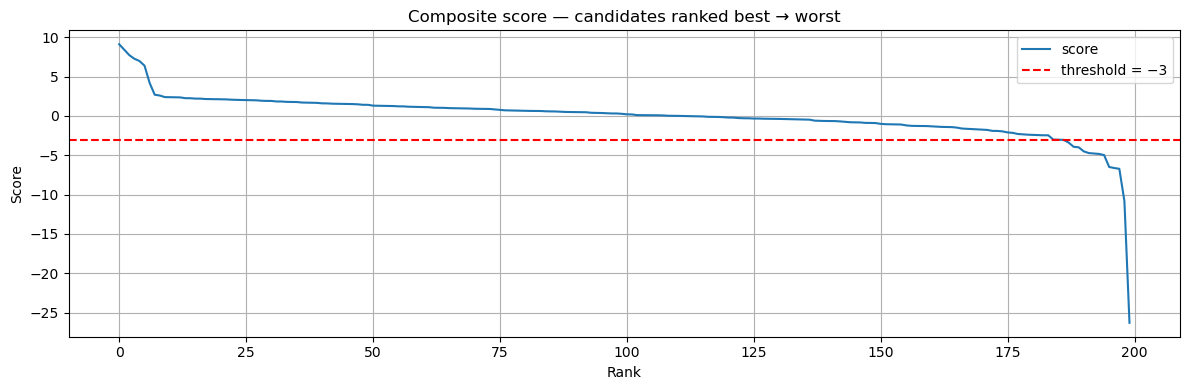

In [11]:
ranked['score'].reset_index(drop=True).plot(
    figsize=(12, 4), grid=True,
    title="Composite score — candidates ranked best → worst",
    xlabel="Rank", ylabel="Score",
)
plt.axhline(-3, color="red", linestyle="--", lw=1.5, label="threshold = −3")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs    = ranked_positive.index
print(f"Candidates: {len(candidates)}  →  Robust pairs (score > −3): {len(robust_pairs)}")

Candidates: 200  →  Robust pairs (score > −3): 184


## 3.4 Pre-filter candidates (composite score)

The composite score from §3.3 is **only a cheap pre-filter** — it narrows the robust pairs down to a short list of candidates. It does **not** pick the traded pair: selecting the single best *in-sample* score is exactly the overfitting trap we want to avoid.

The final pair is chosen in **§3.5** by **walk-forward cross-fold stability**, using only training-span data (2020–2025). The 2026 window (§4b) is never consulted for selection — it stays a genuine held-out test.

In [13]:
# Composite score is a CHEAP PRE-FILTER only — it does NOT pick the final pair.
# Take the top-N robust candidates; the walk-forward driver in §3.5 selects among them.
N_CANDIDATES = 15
wf_candidates = list(robust_pairs[:N_CANDIDATES])

print(f"Pre-filtered to top {len(wf_candidates)} candidates by composite score "
      f"(of {len(robust_pairs)} robust pairs). Final pick is deferred to §3.5.")
for i, (t1, t2) in enumerate(wf_candidates, 1):
    print(f"  {i:2d}. {t1:6s}/{t2:6s}  score={ranked.loc[(t1, t2), 'score']:.3f}")

Pre-filtered to top 15 candidates by composite score (of 184 robust pairs). Final pick is deferred to §3.5.
   1. BKNG  /MA      score=9.113
   2. AVGO  /RL      score=8.416
   3. HSIC  /PLD     score=7.727
   4. NCLH  /REG     score=7.270
   5. NCLH  /ZBH     score=6.985
   6. BA    /JKHY    score=6.385
   7. CRM   /EQIX    score=4.200
   8. NCLH  /SBAC    score=2.697
   9. NCLH  /NTRS    score=2.596
  10. HSIC  /JBHT    score=2.395
  11. NCLH  /WAT     score=2.384
  12. NCLH  /WTW     score=2.369
  13. NCLH  /SPG     score=2.360
  14. NCLH  /VRSN    score=2.259
  15. NCLH  /PSX     score=2.252


## 3.5 Walk-forward selection driver  ← *this* picks the traded pair

We run walk-forward validation (rolling train/test folds over the 2020–2025 training span) on **each** pre-filtered candidate and rank by the **median per-fold Sharpe**. Median rewards pairs whose edge is *consistent across folds* rather than pairs that got one lucky window. `MIN_TOTAL_TRADES` screens out pairs too inactive to judge.

This is the holdout principle done correctly for time series: **selection happens on validation folds**; the 2026 test set in §4b is never touched here. The top-ranked pair becomes `ticker1, ticker2` for everything downstream.

The z-score look-back for each test fold is estimated from the *training* fold's residual, which also warms up the rolling window — the test fold never informs its own z-score (no in-fold look-ahead).

In [14]:
# === Walk-forward selection driver (parallel across candidates) =============
# Each candidate's walk-forward run is independent, so we fan them out with joblib.
# walk_forward_backtest is itself serial (no nested parallelism) and the fit uses the
# single-pair _kalman_dynamic_hedge (no internal process pool) — so the only thing to
# guard against is BLAS thread oversubscription. Pin threads to 1 (as the Kalman module
# does internally) before the worker processes are spawned.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals, estimate_halflife_window
from pairs.strategies.evaluate import evaluate_pair_signals

MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS = -1             # -1 = all cores; each job is one candidate's walk-forward

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    # Filtered (causal) states so the residual history handed to the test fold has the same
    # statistical properties as the causal test-fold residual; the EM fit and the exported
    # end state are unaffected by the choice of mode.
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
    if states is None or params is None:
        return None
    # The z-score look-back is chosen from the TRAINING residual, and that residual is carried
    # along as warm-up history — the test fold never informs its own z-score (no look-ahead).
    params = dict(params)
    params["z_window"]  = estimate_halflife_window(states["resid"])
    params["z_history"] = states["resid"]
    return params

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_window=params["z_window"], z_history=params["z_history"],   # from the training fold
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    """Run walk-forward for one candidate; return ('ok', row) / ('error', ...) / None."""
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    }, res)

# Build the (small) per-candidate inputs up front; skip pairs with too little history.
_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:        # not enough history for even one fold
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
wf_by_pair = {}            # keep each candidate's full per-fold results for reuse
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])
    wf_by_pair[(r[1]["ticker1"], r[1]["ticker2"])] = r[2]

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

ticker1, ticker2 = wf_selection.index[0]
wf_results = wf_by_pair[(ticker1, ticker2)]   # winner's folds, for the detail plot below
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
BKNG    MA                  1.222           1.027          1.263          0.750              124       16            9.113
NCLH    REG                 0.891           0.480          1.539          0.750              114       16            7.270
        SPG                 0.629           0.527          1.126          0.688              118       16            2.360
        NTRS                0.346           0.410          1.518          0.562              136       16            2.596
AVGO    RL                  0.305           0.400          0.937          0.688              107       16            8.416
NCLH    PSX                 0.300           0.006          1

### 3.5.1 Walk-forward detail for the selected pair

§3.5 ranked the shortlist by **median per-fold Sharpe** and selected the pair above. Below is that pair's full per-fold walk-forward distribution — the validation evidence behind the choice, reusing the folds already computed (no recomputation). A tight, mostly-positive distribution is what we want; one that swings sign across folds means the edge is fragile.

=== Walk-forward folds for selected pair BKNG/MA ===

                  mean   std  median    min    max
sharpe           1.027 1.304   1.222 -1.099  3.054
ann_return       0.058 0.081   0.065 -0.097  0.175
max_drawdown_pct 0.025 0.022   0.018  0.008  0.102
n_trades         7.750 2.352   8.000  4.000 12.000
hit_rate         0.718 0.161   0.732  0.333  1.000
profit_factor      inf   NaN   3.274  0.186    inf


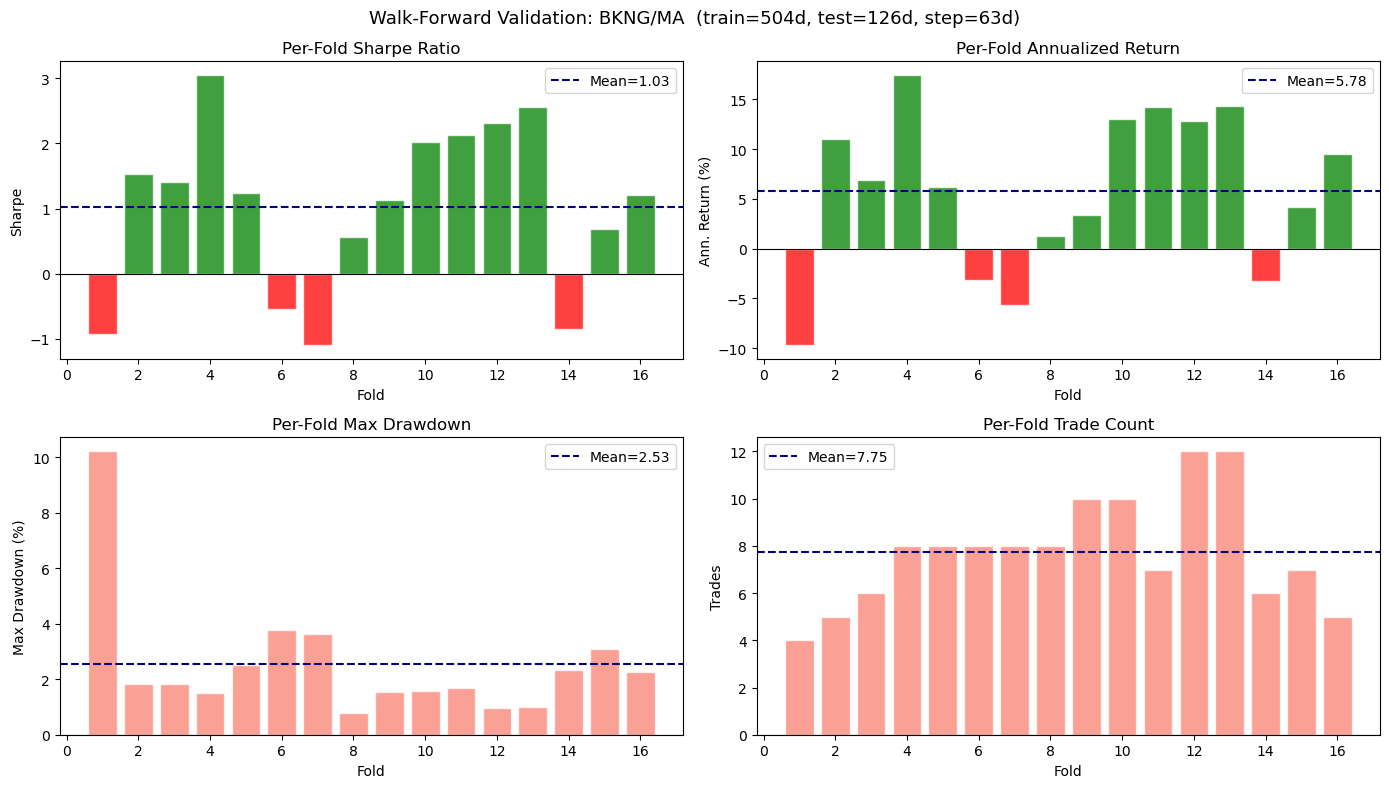


Folds with positive Sharpe : 75%  (12/16)
Median fold Sharpe         : 1.22
Mean fold Sharpe           : 1.03  (std=1.26)


In [15]:
# Per-fold walk-forward detail for the SELECTED pair — reuses wf_results from §3.5
# (no recomputation). nan-robust stats (a zero-trade fold yields a NaN Sharpe).
from pairs.validation.walk_forward import summarize_walk_forward

print(f"=== Walk-forward folds for selected pair {ticker1}/{ticker2} ===\n")
print(summarize_walk_forward(wf_results).to_string(float_format="{:.3f}".format))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {ticker1}/{ticker2}  "
             f"(train=504d, test=126d, step=63d)", fontsize=13)

sharpes  = wf_results["sharpe"].to_numpy(dtype=float)
ann_rets = wf_results["ann_return"].to_numpy(dtype=float) * 100
dds      = wf_results["max_drawdown_pct"].abs().to_numpy(dtype=float) * 100
n_trades = wf_results["n_trades"].to_numpy(dtype=float)
folds    = wf_results.index.values

def _bar(ax, vals, title, ylabel, pos_neg=True):
    colors = ["green" if v > 0 else "red" for v in vals] if pos_neg else "salmon"
    ax.bar(folds, vals, color=colors, alpha=0.75, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(np.nanmean(vals), color="navy", linestyle="--", lw=1.5,
               label=f"Mean={np.nanmean(vals):.2f}")
    ax.set_xlabel("Fold"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()

_bar(axes[0, 0], sharpes,  "Per-Fold Sharpe Ratio",      "Sharpe")
_bar(axes[0, 1], ann_rets, "Per-Fold Annualized Return", "Ann. Return (%)")
_bar(axes[1, 0], dds,      "Per-Fold Max Drawdown",      "Max Drawdown (%)", pos_neg=False)
_bar(axes[1, 1], n_trades, "Per-Fold Trade Count",       "Trades", pos_neg=False)
plt.tight_layout(); plt.show()

pct_pos = float(np.mean(sharpes > 0)) * 100
print(f"\nFolds with positive Sharpe : {pct_pos:.0f}%  ({int((sharpes > 0).sum())}/{len(sharpes)})")
print(f"Median fold Sharpe         : {np.nanmedian(sharpes):.2f}")
print(f"Mean fold Sharpe           : {np.nanmean(sharpes):.2f}  (std={np.nanstd(sharpes):.2f})")

# 4. In-Sample Signal Generation & Evaluation (2020–2025)

## 4.1 Build the pair-aligned DataFrame

In [16]:
df_kf = states_tr[(ticker1, ticker2)]

prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'),
    columns=df_filtered.index.get_level_values('ticker'),
    values='close',
)

df_pair = pd.DataFrame({
    'P1': prices[ticker1],
    'P2': prices[ticker2],
}).join(df_kf[['beta', 'resid']])

print(f"Training pair frame: {df_pair.index[0].date()} → {df_pair.index[-1].date()}, "
      f"{len(df_pair):,} bars")
df_pair.tail(3)

Training pair frame: 2020-01-02 → 2025-12-31, 1,508 bars


,P1,P2,beta,resid
datetime,,,,
2025-12-29,217.653198,577.900024,0.343690,0.062141
2025-12-30,217.085999,577.419983,0.343163,-0.035799
2025-12-31,214.213196,570.880005,0.342126,-0.071359


## 4.2 Generate trading signals

Signal logic:
- **Entry**: |z| > `z_entry` (default 2.0) — spread is extreme
- **Exit** : |z| < `z_exit`  (default 0.5) — spread has mean-reverted
- **Stop** : |z| > `z_stop`  (default 4.0) — spread is diverging

Z-score is computed with the *robust* method (median/MAD) which is less sensitive to outliers.

In [17]:
from pairs.strategies import generate_pair_signals

signals = generate_pair_signals(
    df_pair,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,
    cooldown_bars=0,
)
signals.tail(5)

,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2025-12-24,-0.428719,0,0.0,0.0,False,False,False
2025-12-26,-0.191140,0,0.0,0.0,False,False,False
2025-12-29,-0.015958,0,0.0,0.0,False,False,False
2025-12-30,-0.196630,0,0.0,0.0,False,False,False
2025-12-31,-0.362246,0,0.0,0.0,False,False,False


## 4.3 Visualize in-sample trades

(<Figure size 1300x1050 with 3 Axes>,
 (<Axes: title={'center': 'Trades superimposed on each leg • BKNG (top), MA (bottom)'}, ylabel='Price'>,
  <Axes: ylabel='Price'>,
  <Axes: title={'center': 'Spread z-score — entries when it leaves the band, exits as it reverts'}, ylabel='z'>))

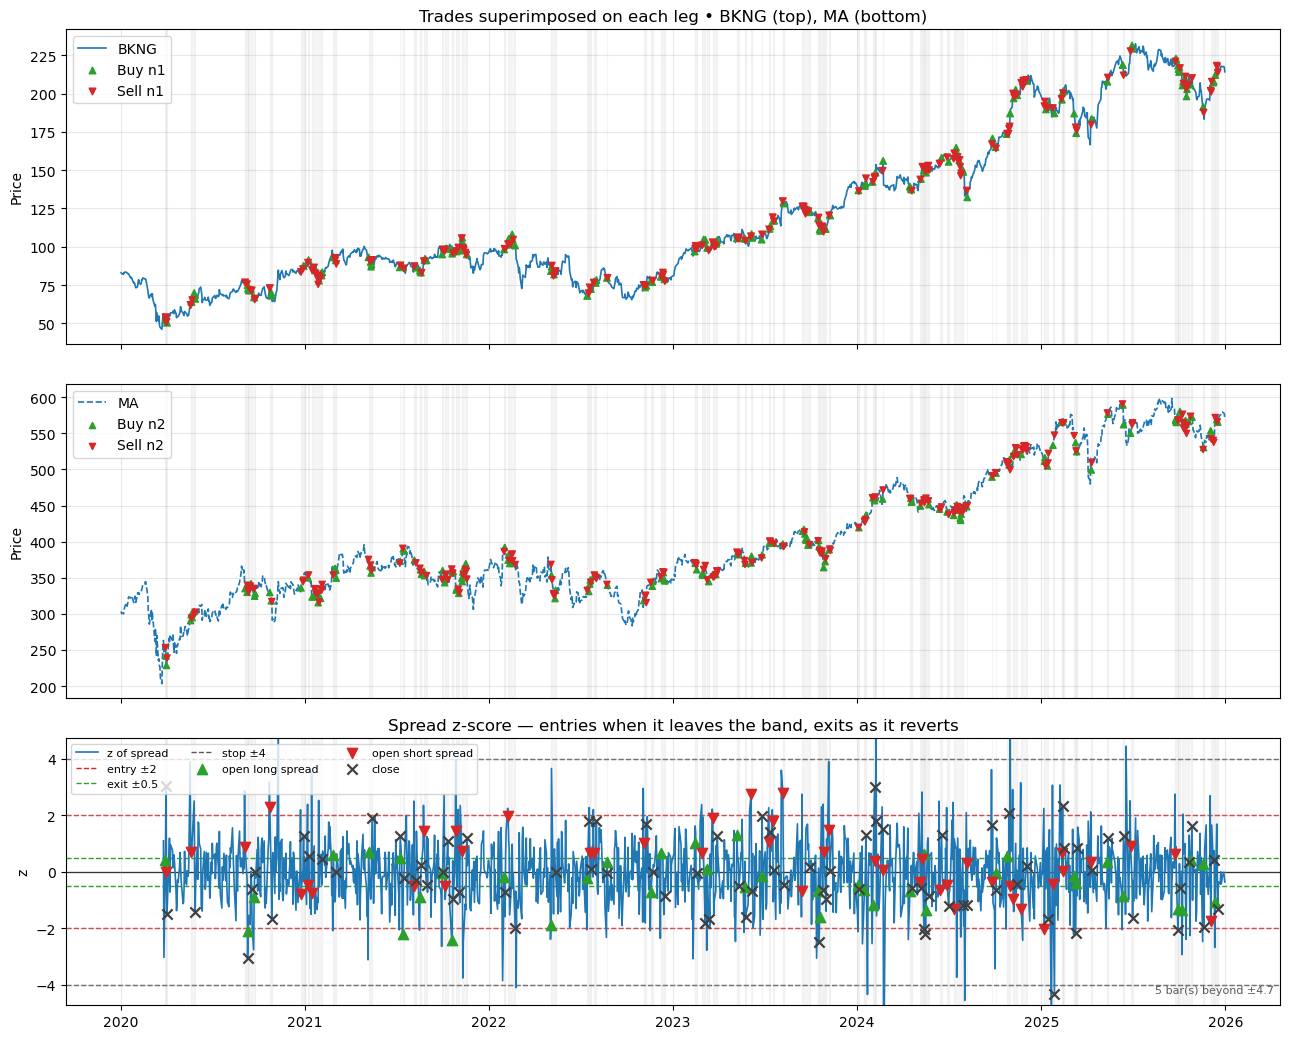

In [18]:
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair, signals,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
    show_zscore=True, z_entry=2.0, z_exit=0.5, z_stop=4.0,
)

## 4.4 In-sample performance metrics

In [19]:
from pairs import evaluate_pair_signals

daily_tr, trades_tr, summary_tr = evaluate_pair_signals(
    df_pair, signals,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== In-Sample Performance (2020-01-02 → 2025-12-31) ===")
print(pd.Series(summary_tr).to_string())

=== In-Sample Performance (2020-01-02 → 2025-12-31) ===
start                       2020-01-02 00:00:00
end                         2025-12-31 00:00:00
bars                                       1508
capital_base                        10004.60448
gross_pnl                           1992.901453
net_pnl                             1794.505533
ann_return                              0.02869
sharpe                                 0.515717
max_drawdown                         872.099587
max_drawdown_pct                       0.084032
avg_gross_exposure                  1698.151802
avg_exposure_utilization               0.999857
turnover_annualized                   28.824608
n_trades                                     85
hit_rate                                    0.6
avg_win                               96.568933
avg_loss                             -92.073825
profit_factor                          1.573231
avg_hold_bars                          3.011765
med_hold_bars                   

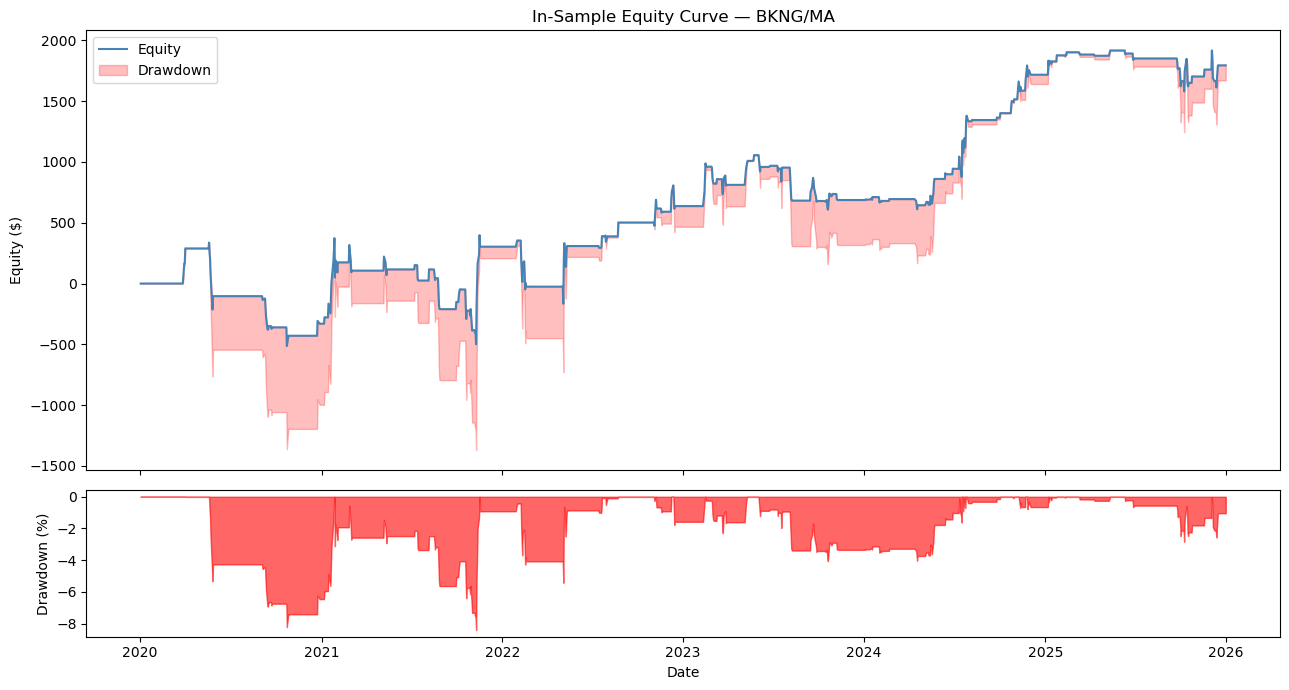

In [20]:
# Equity curve with drawdown shading
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(daily_tr.index, daily_tr["equity"], color="steelblue", lw=1.5, label="Equity")
ax1.fill_between(daily_tr.index, daily_tr["equity"],
                 daily_tr["equity"] + daily_tr["drawdown"],   # drawdown is negative
                 alpha=0.25, color="red", label="Drawdown")
ax1.set_ylabel("Equity ($)"); ax1.set_title(f"In-Sample Equity Curve — {ticker1}/{ticker2}")
ax1.legend()

ax2.fill_between(daily_tr.index, daily_tr["drawdown_pct"] * 100, 0,
                 alpha=0.6, color="red")
ax2.set_ylabel("Drawdown (%)"); ax2.set_xlabel("Date")
plt.tight_layout(); plt.show()

# 4b. Out-of-Sample Evaluation (2026-01-01 → 2026-06-25)

## 4b.1 Download OOS price data

In [21]:
start_test = "2026-01-01"
end_test   = "2026-06-25"

_oos_cache = CACHE / f"nb03_oos_{ticker1}_{ticker2}_{start_test}_{end_test}.parquet"
if _oos_cache.exists():
    df_test, failed = pd.read_parquet(_oos_cache), []
else:
    df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)
    df_test.to_parquet(_oos_cache)
print(f"OOS data: {len(df_test):,} rows, {df_test.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

OOS data: 240 rows, 2 tickers


## 4b.2 Continue Kalman filter on OOS window (no look-ahead)

We freeze the parameters $(F, Q, R)$ learned during training and **continue filtering**
from the last train state.  The smoother is NOT used on OOS data — only the causal filter.

The OOS z-score uses a look-back chosen from — and warmed up on — the causal *training-window* residual under the same frozen parameters, so the OOS window never informs its own z-score.

In [22]:
from pairs import filter_kf_on_new

pair = (ticker1, ticker2)
frozen = {k: params_tr[pair][k] for k in ("F", "Q", "R")}
last_state = (params_tr[pair]["last_state_mean"], params_tr[pair]["last_state_cov"])

P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']

states_te, _ = filter_kf_on_new(
    P1_new, P2_new,
    frozen=frozen,
    last_state=last_state,
    init_cov=1e6,
    mode="filter",
)

prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close",
)
df_pair_te = states_te.join(
    prices_te[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}),
    how="inner",
)
print(f"OOS pair frame: {df_pair_te.index[0].date()} → {df_pair_te.index[-1].date()}, "
      f"{len(df_pair_te):,} bars")

OOS pair frame: 2026-01-02 → 2026-06-25, 120 bars


In [23]:
# z-score look-back and warm-up history from the causal TRAINING residual under the frozen
# parameters — the OOS window never informs its own z-score (no in-window look-ahead).
states_hist, _ = filter_kf_on_new(
    df_pair["P1"], df_pair["P2"],
    frozen=frozen, last_state=None, init_cov=1e6, mode="filter",
)
z_window_tr = estimate_halflife_window(states_hist["resid"])
print(f"z-score window from training residual: {z_window_tr} bars")

signals_te = generate_pair_signals(
    df_pair_te,
    z_method="robust",
    z_window=z_window_tr, z_history=states_hist["resid"],
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
)
daily_te, trades_te, summary_te = evaluate_pair_signals(
    df_pair_te[["P1", "P2"]], signals_te,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===")
print(pd.Series(summary_te).to_string())

z-score window from training residual: 30 bars
=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===
start                       2026-01-02 00:00:00
end                         2026-06-25 00:00:00
bars                                        120
capital_base                        9989.325853
gross_pnl                            692.138223
net_pnl                              664.302195
ann_return                              0.14823
sharpe                                  2.64203
max_drawdown                         243.954955
max_drawdown_pct                        0.02313
avg_gross_exposure                  2249.102743
avg_exposure_utilization               1.000669
turnover_annualized                   52.771994
n_trades                                     12
hit_rate                                   0.75
avg_win                               88.373177
avg_loss                             -66.854738
profit_factor                          3.965606
avg_hold_bars                

## 4b.3 Visualize OOS trades

The same view as the in-sample plot (§4.3), now on the 2026 held-out window. Reading it next to §4.3 makes the shorter window concrete: 13 holding periods here against 85 across the five-year training span — though over only 120 bars, so the *rate* of trading is actually higher out of sample.

(<Figure size 1300x1050 with 3 Axes>,
 (<Axes: title={'center': 'Trades superimposed on each leg • BKNG (top), MA (bottom)'}, ylabel='Price'>,
  <Axes: ylabel='Price'>,
  <Axes: title={'center': 'Spread z-score — entries when it leaves the band, exits as it reverts'}, ylabel='z'>))

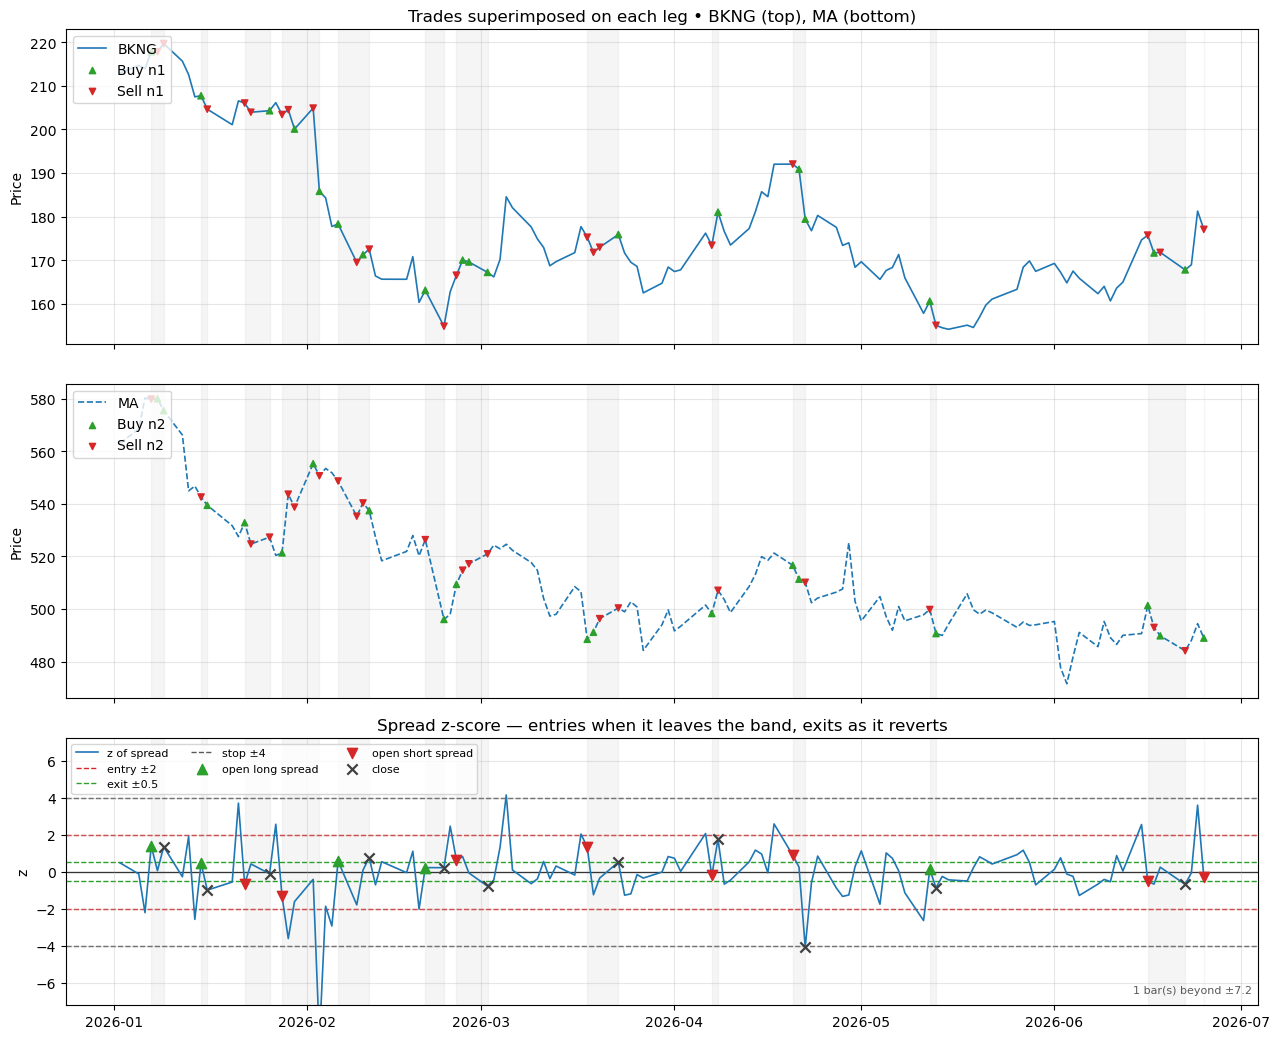

In [24]:
# Same plot as in-sample (§4.3), applied to the OOS pair frame & signals.
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_te, signals_te,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
    show_zscore=True, z_entry=2.0, z_exit=0.5, z_stop=4.0,
)

## 4b.4 In-sample vs OOS comparison

> ⚠️ **Caution**: The OOS window contains only **13 trades** over 120 bars. A hit rate of
> 84.6% on 13 observations is statistically uninformative — the 95% binomial CI spans roughly
> (55%, 98%). Note the direction: the OOS Sharpe (3.50) is *higher* than the in-sample figure
> (0.52), which is not evidence that the strategy improved. The standard error of an annualized
> Sharpe over 120 bars is about 1.4, so 3.50 is a high-variance draw, not a result.

In [25]:
comparison = pd.DataFrame({
    "In-sample (2020-2025)": pd.Series(summary_tr),
    "OOS (2026)":            pd.Series(summary_te),
}).loc[["sharpe", "ann_return", "max_drawdown_pct", "n_trades", "hit_rate", "profit_factor"]]
comparison.loc["ann_return"] = comparison.loc["ann_return"] * 100   # → %
comparison.index = ["Sharpe", "Ann. Return (%)", "Max Drawdown (%)", "Trades", "Hit Rate", "Profit Factor"]
print(comparison.to_string(float_format="{:.3f}".format))

                 In-sample (2020-2025) OOS (2026)
Sharpe                           0.516      2.642
Ann. Return (%)                  2.869     14.823
Max Drawdown (%)                 0.084      0.023
Trades                              85         12
Hit Rate                         0.600      0.750
Profit Factor                    1.573      3.966


# 8. Limitations and Honest Assessment

## 8.1 What the results cannot tell us

The traded pair was chosen (§3.5) from a shortlist that itself survived a composite stationarity filter over a very large number of simultaneously-tested pairs. Read the performance with these caveats:

- **Selection bias (identical to nb02, not amplified).** Dropping Benjamini-Hochberg marks far more pairs `pass`, but the candidate set is a rank cut on raw p-values that BH does not reorder, so this notebook's shortlist, selected pair and results match `pairs_trading_02_yahoo.ipynb` exactly (§0). The selection bias is real and is the same in both. To make the ablation bite, gate candidates on `verdict` before the rank cut.
- **Low OOS trade count.** The OOS window produces only a handful of trades (13 for the selected BKNG/MA pair) — far below the ~50 needed for statistical power. A high hit rate on a few trades is uninformative.
- **Single-window Sharpe is noise in both directions.** In-sample Sharpe is systematically optimistic, so the OOS figure is *usually* lower — but in this run it is higher (0.52 → 3.50) on 13 trades in half a year. Neither single window is informative: the fold distribution in §3.5 is.
- **Optimistic cost model.** The in-sample/OOS evaluation uses a flat `cost_bps` with no market impact, fill/queue uncertainty, or borrow-availability variability.
- **Single-pair analysis.** A live strategy trades a *portfolio* of pairs — introducing cross-pair residual correlation, portfolio-level drawdown management, and signal interaction effects not captured here.

## 8.2 What the evidence does support

1. A working end-to-end pipeline (data → cointegration → Kalman hedge → signals → evaluation) with **causal OOS continuation** (no look-ahead: the Kalman state is carried forward, and the z-score look-back and its warm-up come from training data, never from the window being scored).
2. **Honest pair selection**: the traded pair is chosen by walk-forward cross-fold stability (§3.5), not by in-sample ranking — and the held-out window is never used for selection.
3. **Multiple-testing _not_ corrected**: this variant omits BH FDR (the deliberate difference from nb02), so statistically spurious pairs that BH would remove stay in the candidate set.
4. **Honest degradation disclosure**: the OOS Sharpe is reported, not hidden, and the walk-forward distribution (§3.5.1) shows the spread across folds rather than one window.

## 8.3 Gap-to-production

| Gap | Required mitigation |
|-----|---------------------|
| Selection bias | Strict hold-out from inception; **add BH FDR** (omitted here — see nb02) + walk-forward selection |
| Low OOS N | Longer OOS window; portfolio of 10+ pairs |
| No market impact | Square-root impact model + capacity analysis |
| Single-regime OOS | Rolling re-estimation in live trading |
| No portfolio risk mgmt | Residual-vol position sizing; cross-pair correlation |
| Borrow / execution | Pre-borrow checks; limit-order fill model |